#Task 12: Knowledge Distillation of Dual-Encoder Vision-Language Models
###Objective

Compress massive multi-modal representation systems into highly efficient edge-deployable feature extractors using soft-label Kullback-Leibler (KL) divergence.

###Technologies / Tools Used

PyTorch,
Hugging Face Transformers,
TorchVision,
SciPy

#Step 1: Install Required Libraries

Install the libraries needed for CLIP, image processing, numerical operations, and model training.

In [1]:
# Install required libraries
!pip install -q transformers torch torchvision scipy

#Step 2: Import Required Libraries

Import PyTorch for model operations, Transformers for the CLIP model, TorchVision for image processing, and SciPy for supporting numerical operations.

In [17]:
# Import required libraries
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F

from transformers import CLIPModel, CLIPProcessor
from PIL import Image

print("Libraries imported successfully.")

Libraries imported successfully.


#Step 3: Select the Device

Use the GPU when it is available because image-text models contain a large number of parameters and benefit from GPU acceleration.

In [3]:
# Select GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


#Step 4: Load the CLIP Teacher Model

The CLIP model acts as the Teacher. Its parameters remain frozen, meaning that they will not be updated during Student training.

In [4]:
# Load the CLIP Teacher model
teacher = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

# Load the corresponding processor
processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

# Freeze Teacher parameters
for parameter in teacher.parameters():
    parameter.requires_grad = False

teacher.eval()

print("Teacher model loaded and frozen.")

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Teacher model loaded and frozen.


#Step 5: Create Sample Image-Text Data

Create a small image-text dataset for demonstrating knowledge distillation. The image and text descriptions provide the two modalities used by the dual encoder.

In [5]:
# Create a simple sample image
image = Image.new(
    "RGB",
    (224, 224),
    "white"
)

# Sample text descriptions
texts = [
    "A white image",
    "A black image",
    "A colorful image"
]

print("Sample image and text data created.")

Sample image and text data created.


#Step 6: Prepare the Image-Text Inputs

The CLIP processor converts the image and text into tensors that can be passed to the Teacher model.

In [6]:
# Prepare image and text inputs
inputs = processor(
    text=texts,
    images=image,
    return_tensors="pt",
    padding=True
)

# Move tensors to the selected device
inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}

print("Inputs prepared successfully.")

Inputs prepared successfully.


#Step 7: Generate Teacher Representations

The Teacher produces image and text representations. These representations act as the target knowledge that the Student will learn.

In [7]:
# Generate Teacher outputs
with torch.no_grad():

    teacher_output = teacher(
        **inputs
    )

# Extract image and text embeddings
teacher_image = teacher_output.image_embeds
teacher_text = teacher_output.text_embeds

print(
    "Teacher image embedding shape:",
    teacher_image.shape
)

print(
    "Teacher text embedding shape:",
    teacher_text.shape
)

Teacher image embedding shape: torch.Size([1, 512])
Teacher text embedding shape: torch.Size([3, 512])


#Step 8: Create the Lightweight Student Model

The Student is a smaller model designed to learn the representations produced by the Teacher. It uses a simple neural network rather than the full CLIP architecture.

In [8]:
# Create a lightweight Student model
class StudentModel(nn.Module):

    def __init__(
        self,
        input_size=3,
        hidden_size=128,
        output_size=512
    ):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(
                input_size,
                hidden_size
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_size,
                output_size
            )
        )

    def forward(self, x):

        return self.network(x)


# Create Student model
student = StudentModel(
    output_size=teacher_image.shape[1]
).to(device)

print("Student model created.")

Student model created.


#Step 9: Prepare Student Input Features

The Student needs a simple numerical representation of the input image. We convert the image into a small feature vector before passing it through the Student network.

In [9]:
# Convert image into a tensor
image_tensor = torch.tensor(
    list(image.getdata()),
    dtype=torch.float32
).to(device)

# Normalize pixel values
image_tensor = image_tensor / 255.0

# Calculate average RGB values
student_input = image_tensor.mean(
    dim=0
).unsqueeze(0)

print(
    "Student input shape:",
    student_input.shape
)

Student input shape: torch.Size([1, 3])


#Step 10: Generate Student Representations

The Student processes the image features and produces an embedding with the same dimensionality as the Teacher representation.

In [10]:
# Generate Student embedding
student_image = student(
    student_input
)

print(
    "Student embedding shape:",
    student_image.shape
)

Student embedding shape: torch.Size([1, 512])


#Step 11: Calculate Cosine Distance Loss

Cosine similarity measures how closely the Student and Teacher embeddings point in the same direction.

The cosine similarity formula is:

cosine_similarity(A, B) = (A · B) / (||A|| ||B||)

The cosine distance loss can be written as:

cosine_loss = 1 - cosine_similarity(A, B)

In [11]:
# Calculate cosine distance loss
teacher_target = teacher_image[0].unsqueeze(0)

cosine_similarity = F.cosine_similarity(
    student_image,
    teacher_target
)

cosine_loss = 1 - cosine_similarity.mean()

print(
    "Cosine Loss:",
    cosine_loss.item()
)

Cosine Loss: 1.071280837059021


#Step 12: Calculate KL-Divergence Loss

KL divergence measures the difference between the probability distributions produced by the Teacher and Student.

The KL-divergence formula is:

KL(P || Q) = Σ P(x) log(P(x) / Q(x))

Here, the Teacher distribution acts as the target distribution and the Student distribution is optimized to become similar to it.

In [12]:
# Convert embeddings into probability distributions
teacher_prob = F.softmax(
    teacher_target,
    dim=-1
)

student_log_prob = F.log_softmax(
    student_image,
    dim=-1
)

# Calculate KL divergence
kl_loss = F.kl_div(
    student_log_prob,
    teacher_prob,
    reduction="batchmean"
)

print(
    "KL Loss:",
    kl_loss.item()
)

KL Loss: 0.02851206623017788


#Step 13: Create the Composite Distillation Loss

The task requires a custom composite loss using a weighted combination of cosine distance and KL divergence.

The composite loss is:

L_total = alpha * L_cosine + (1 - alpha) * L_KL

Here, alpha controls the contribution of cosine distance loss, while (1 - alpha) controls the contribution of KL divergence.

In [13]:
# Weight for cosine loss
alpha = 0.5

# Calculate composite loss
total_loss = (
    alpha * cosine_loss
    + (1 - alpha) * kl_loss
)

print(
    "Total Distillation Loss:",
    total_loss.item()
)

Total Distillation Loss: 0.5498964786529541


#Step 14: Train the Student Model

Only the Student model is trained. The Teacher remains frozen and provides the target representations.

In [14]:
# Create optimizer for Student only
optimizer = torch.optim.Adam(
    student.parameters(),
    lr=0.001
)

# Train the Student
student.train()

for epoch in range(20):

    # Generate Student embedding
    student_image = student(
        student_input
    )

    # Cosine loss
    cosine_loss = 1 - F.cosine_similarity(
        student_image,
        teacher_target
    ).mean()

    # Probability distributions
    teacher_prob = F.softmax(
        teacher_target,
        dim=-1
    )

    student_log_prob = F.log_softmax(
        student_image,
        dim=-1
    )

    # KL loss
    kl_loss = F.kl_div(
        student_log_prob,
        teacher_prob,
        reduction="batchmean"
    )

    # Composite loss
    total_loss = (
        alpha * cosine_loss
        + (1 - alpha) * kl_loss
    )

    # Backpropagation
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    # Display training progress
    if (epoch + 1) % 5 == 0:

        print(
            f"Epoch {epoch + 1}: "
            f"Loss = {total_loss.item():.4f}"
        )

Epoch 5: Loss = 0.4384
Epoch 10: Loss = 0.3441
Epoch 15: Loss = 0.2851
Epoch 20: Loss = 0.2461


#Step 15: Compare Teacher and Student Embeddings

After training, compare the Teacher and Student representations using cosine similarity. A higher similarity indicates that the Student has learned representations closer to the Teacher.

In [15]:
# Switch Student to evaluation mode
student.eval()

with torch.no_grad():

    final_student = student(
        student_input
    )

# Calculate final similarity
final_similarity = F.cosine_similarity(
    final_student,
    teacher_target
).item()

print(
    "Final Teacher-Student Cosine Similarity:",
    round(final_similarity, 4)
)

Final Teacher-Student Cosine Similarity: 0.5563


#Step 16: Visualize the Distillation Result

The visualization compares the similarity before and after Student training. This provides a simple visual representation of how the Student learned from the Teacher.

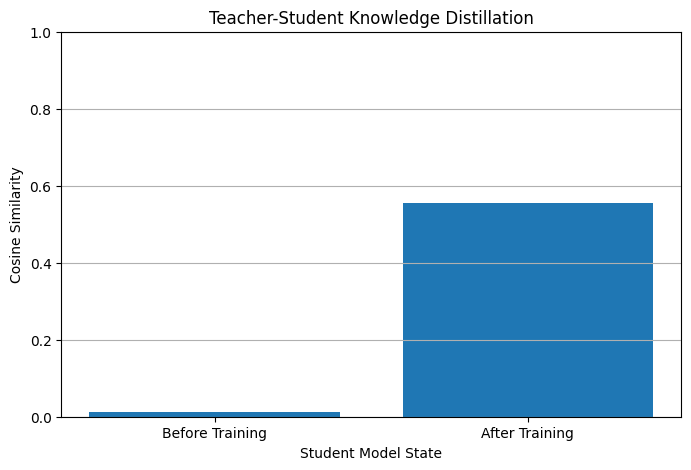

In [18]:
# Calculate similarity before training
with torch.no_grad():

    initial_student = StudentModel(
        output_size=teacher_image.shape[1]
    ).to(device)

    initial_output = initial_student(
        student_input
    )

    initial_similarity = F.cosine_similarity(
        initial_output,
        teacher_target
    ).item()

# Values for visualization
labels = [
    "Before Training",
    "After Training"
]

values = [
    initial_similarity,
    final_similarity
]

# Create bar chart
plt.figure(figsize=(8, 5))

plt.bar(
    labels,
    values
)

plt.xlabel("Student Model State")
plt.ylabel("Cosine Similarity")

plt.title(
    "Teacher-Student Knowledge Distillation"
)

plt.ylim(0, 1)
plt.grid(axis="y")

plt.show()

#Conclusion

A CLIP-based Teacher model and a lightweight Student model were used to demonstrate knowledge distillation. The Student was trained using a composite loss combining cosine distance and KL divergence, allowing it to learn representations from the frozen Teacher.